# Baseline Models - Financial Complaint Classification

This notebook compares several baseline text-classification models for predicting the financial product category from a complaint narrative.

The workflow is intentionally simple and interpretable:

1. Clean the data and remove exact duplicate narratives.
2. Create a stratified train/test split.
3. Use a validation split from the training data for model selection.
4. Compare simple Bag of Words and TF-IDF baselines.
5. Select the top 3 models using validation **macro F1**.
6. Tune only those top 3 models.
7. Evaluate the selected model once on the held-out test set.

Because the classes are imbalanced, the main metric is **macro F1**, not accuracy.

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import joblib

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 140)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load Data

The notebook expects `complaints_processed.csv` to be in the project root, one level above the `notebooks/` folder.

In [2]:
data_path = '../complaints_processed.csv'

df = pd.read_csv(data_path, index_col=0)
df.columns = df.columns.str.lower()
df = df[['product', 'narrative']].copy()

print(df.shape)
df.head()

(162421, 2)


,product,narrative
0,credit_card,purchase order day shipping amount receive product week sent followup email exact verbiage paid two day shipping received order company ...
1,credit_card,forwarded message date tue subject please investigate comenity bank retailer card scam sent hello name scammed comenity bank credit card...
2,retail_banking,forwarded message cc sent friday pdt subject final legal payment well fargo well fargo clearly wrong need look actually opened account s...
3,credit_reporting,payment history missing credit report specialized loan servicing sl made mistake put account forbearance without authorization knowledge...
4,credit_reporting,payment history missing credit report made mistake put account forbearance without authorization knowledge matter fact automatic payment...


## 3. Basic Cleaning

The model uses the already processed complaint text. The cleaning step removes missing/empty narratives and exact duplicate narratives.

Removing exact duplicate text before splitting helps avoid leakage, because the same complaint narrative should not appear in both training and test data.

In [3]:
model_data = df.dropna(subset=['product', 'narrative']).copy()
model_data['narrative'] = model_data['narrative'].astype(str).str.strip()
model_data = model_data[model_data['narrative'].ne('')].copy()

rows_before_dedup = len(model_data)
model_data = model_data.drop_duplicates(subset='narrative').copy()
duplicates_removed = rows_before_dedup - len(model_data)

print('Rows after cleaning:', len(model_data))
print('Exact duplicate narratives removed:', duplicates_removed)
print('Product categories:', model_data['product'].nunique())

display(
    model_data['product']
    .value_counts()
    .rename_axis('product')
    .reset_index(name='complaints')
)

Rows after cleaning: 124472
Exact duplicate narratives removed: 37939
Product categories: 5


,product,complaints
0,credit_reporting,56240
1,debt_collection,21057
2,mortgages_and_loans,18723
3,credit_card,14983
4,retail_banking,13469


## 4. Train, Validation, and Test Split

The test set is held out until the end. Model comparison and tuning use only a validation split from the training data.

In [4]:
X = model_data['narrative']
y = model_data['product']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train,
)

print('Fit rows:', len(X_fit))
print('Validation rows:', len(X_val))
print('Test rows:', len(X_test))

split_check = pd.DataFrame({
    'fit_pct': (y_fit.value_counts(normalize=True) * 100).round(2),
    'validation_pct': (y_val.value_counts(normalize=True) * 100).round(2),
    'test_pct': (y_test.value_counts(normalize=True) * 100).round(2),
})
display(split_check)

Fit rows: 79661
Validation rows: 19916
Test rows: 24895


,fit_pct,validation_pct,test_pct
product,,,
credit_reporting,45.18,45.18,45.18
debt_collection,16.92,16.92,16.92
mortgages_and_loans,15.04,15.04,15.04
credit_card,12.04,12.04,12.04
retail_banking,10.82,10.82,10.82


## 5. Simple Baseline Comparison

This section compares a range of simple models before tuning anything.

Included baselines:

- Dummy majority-class classifier
- Bag of Words + Naive Bayes
- Bag of Words + Logistic Regression
- Bag of Words + Linear SVM
- TF-IDF + Naive Bayes
- TF-IDF + Logistic Regression
- TF-IDF + SGD
- TF-IDF + Linear SVM

The comparison uses validation macro F1, because this is an imbalanced multi-class problem.

In [5]:
def score_model(model_name, pipeline, X_fit, y_fit, X_val, y_val):
    pipeline.fit(X_fit, y_fit)
    val_pred = pipeline.predict(X_val)
    return {
        'model_name': model_name,
        'macro_f1': f1_score(y_val, val_pred, average='macro'),
        'weighted_f1': f1_score(y_val, val_pred, average='weighted'),
    }

bow = CountVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.90,
    max_features=50000,
    stop_words='english',
)

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.90,
    max_features=50000,
    stop_words='english',
)

baseline_candidates = [
    ('Dummy_most_frequent', Pipeline([
        ('clf', DummyClassifier(strategy='most_frequent')),
    ])),
    ('BOW_MultinomialNB', Pipeline([
        ('vectorizer', bow),
        ('clf', MultinomialNB(alpha=0.5)),
    ])),
    ('BOW_ComplementNB', Pipeline([
        ('vectorizer', bow),
        ('clf', ComplementNB(alpha=0.5)),
    ])),
    ('BOW_LogisticRegression', Pipeline([
        ('vectorizer', bow),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', solver='saga', random_state=42)),
    ])),
    ('BOW_LinearSVC', Pipeline([
        ('vectorizer', bow),
        ('clf', LinearSVC(class_weight='balanced', C=1.0, random_state=42)),
    ])),
    ('TFIDF_MultinomialNB', Pipeline([
        ('vectorizer', tfidf),
        ('clf', MultinomialNB(alpha=0.5)),
    ])),
    ('TFIDF_ComplementNB', Pipeline([
        ('vectorizer', tfidf),
        ('clf', ComplementNB(alpha=0.5)),
    ])),
    ('TFIDF_LogisticRegression', Pipeline([
        ('vectorizer', tfidf),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', solver='saga', random_state=42)),
    ])),
    ('TFIDF_SGD_hinge', Pipeline([
        ('vectorizer', tfidf),
        ('clf', SGDClassifier(loss='hinge', class_weight='balanced', random_state=42, max_iter=1000, tol=1e-3)),
    ])),
    ('TFIDF_LinearSVC', Pipeline([
        ('vectorizer', tfidf),
        ('clf', LinearSVC(class_weight='balanced', C=1.0, random_state=42)),
    ])),
]

baseline_results = []
for model_name, pipeline in baseline_candidates:
    baseline_results.append(score_model(model_name, pipeline, X_fit, y_fit, X_val, y_val))

baseline_results = pd.DataFrame(baseline_results).sort_values('macro_f1', ascending=False)
display(baseline_results.round(4))

,model_name,macro_f1,weighted_f1
9,TFIDF_LinearSVC,0.8389,0.8538
7,TFIDF_LogisticRegression,0.8310,0.8416
8,TFIDF_SGD_hinge,0.8284,0.8409
3,BOW_LogisticRegression,0.8254,0.8378
5,TFIDF_MultinomialNB,0.8123,0.8262
4,BOW_LinearSVC,0.8056,0.8279
6,TFIDF_ComplementNB,0.8054,0.8212
1,BOW_MultinomialNB,0.7967,0.8090
2,BOW_ComplementNB,0.7930,0.8092
0,Dummy_most_frequent,0.1245,0.2813


**Baseline comparison comments**

- The dummy classifier gives the minimum reference point and confirms that accuracy would be misleading for this imbalanced dataset.
- Bag of Words models are useful simple baselines, but TF-IDF models perform better overall.
- Linear SVM with TF-IDF is the strongest untuned baseline by validation macro F1.
- The top 3 models are selected for the next step instead of tuning every model.

In [6]:
top_3_model_names = baseline_results.head(3)['model_name'].tolist()
print('Top 3 models selected for tuning:')
for model_name in top_3_model_names:
    print('-', model_name)

Top 3 models selected for tuning:
- TFIDF_LinearSVC
- TFIDF_LogisticRegression
- TFIDF_SGD_hinge


## 6. Tune the Top 3 Models

Only the top 3 validation models are tuned. This keeps the workflow focused and avoids spending time on weak model families.

In [7]:
tuning_candidates = []

if 'TFIDF_LinearSVC' in top_3_model_names:
    for ngram_range, min_df, max_features, C in [
        ((1, 2), 5, 50000, 1.0),
        ((1, 2), 3, 100000, 1.0),
        ((1, 3), 3, 100000, 1.0),
        ((1, 3), 3, 100000, 0.5),
    ]:
        tuning_candidates.append((
            f'TFIDF_LinearSVC_ngram{ngram_range}_min{min_df}_C{C}',
            Pipeline([
                ('vectorizer', TfidfVectorizer(
                    ngram_range=ngram_range,
                    min_df=min_df,
                    max_df=0.95,
                    max_features=max_features,
                    stop_words='english',
                )),
                ('clf', LinearSVC(class_weight='balanced', C=C, random_state=42)),
            ])
        ))

if 'BOW_LinearSVC' in top_3_model_names:
    for ngram_range, min_df, max_features, C in [
        ((1, 2), 5, 50000, 1.0),
        ((1, 2), 3, 100000, 1.0),
        ((1, 3), 3, 100000, 0.5),
    ]:
        tuning_candidates.append((
            f'BOW_LinearSVC_ngram{ngram_range}_min{min_df}_C{C}',
            Pipeline([
                ('vectorizer', CountVectorizer(
                    ngram_range=ngram_range,
                    min_df=min_df,
                    max_df=0.95,
                    max_features=max_features,
                    stop_words='english',
                )),
                ('clf', LinearSVC(class_weight='balanced', C=C, random_state=42)),
            ])
        ))

if 'TFIDF_LogisticRegression' in top_3_model_names:
    for ngram_range, min_df, max_features, C in [
        ((1, 2), 5, 50000, 1.0),
        ((1, 2), 3, 100000, 1.0),
        ((1, 3), 3, 100000, 0.5),
    ]:
        tuning_candidates.append((
            f'TFIDF_LogReg_ngram{ngram_range}_min{min_df}_C{C}',
            Pipeline([
                ('vectorizer', TfidfVectorizer(
                    ngram_range=ngram_range,
                    min_df=min_df,
                    max_df=0.95,
                    max_features=max_features,
                    stop_words='english',
                )),
                ('clf', LogisticRegression(
                    max_iter=1000,
                    class_weight='balanced',
                    solver='saga',
                    C=C,
                    random_state=42,
                )),
            ])
        ))

if 'TFIDF_SGD_hinge' in top_3_model_names:
    for ngram_range, min_df, max_features, alpha in [
        ((1, 2), 5, 50000, 0.0001),
        ((1, 2), 3, 100000, 0.0001),
        ((1, 3), 3, 100000, 0.00001),
    ]:
        tuning_candidates.append((
            f'TFIDF_SGD_hinge_ngram{ngram_range}_min{min_df}_alpha{alpha}',
            Pipeline([
                ('vectorizer', TfidfVectorizer(
                    ngram_range=ngram_range,
                    min_df=min_df,
                    max_df=0.95,
                    max_features=max_features,
                    stop_words='english',
                )),
                ('clf', SGDClassifier(
                    loss='hinge',
                    class_weight='balanced',
                    alpha=alpha,
                    random_state=42,
                    max_iter=1000,
                    tol=1e-3,
                )),
            ])
        ))

tuning_results = []
for model_name, pipeline in tuning_candidates:
    tuning_results.append(score_model(model_name, pipeline, X_fit, y_fit, X_val, y_val))

tuning_results = pd.DataFrame(tuning_results).sort_values('macro_f1', ascending=False)
display(tuning_results.round(4))

,model_name,macro_f1,weighted_f1
3,"TFIDF_LinearSVC_ngram(1, 3)_min3_C0.5",0.8460,0.8594
2,"TFIDF_LinearSVC_ngram(1, 3)_min3_C1.0",0.8447,0.8593
9,"TFIDF_SGD_hinge_ngram(1, 3)_min3_alpha1e-05",0.8442,0.8574
1,"TFIDF_LinearSVC_ngram(1, 2)_min3_C1.0",0.8440,0.8585
0,"TFIDF_LinearSVC_ngram(1, 2)_min5_C1.0",0.8389,0.8538
5,"TFIDF_LogReg_ngram(1, 2)_min3_C1.0",0.8313,0.8420
4,"TFIDF_LogReg_ngram(1, 2)_min5_C1.0",0.8310,0.8416
6,"TFIDF_LogReg_ngram(1, 3)_min3_C0.5",0.8294,0.8396
8,"TFIDF_SGD_hinge_ngram(1, 2)_min3_alpha0.0001",0.8289,0.8411
7,"TFIDF_SGD_hinge_ngram(1, 2)_min5_alpha0.0001",0.8284,0.8409


**Tuning comments**

- The best tuned model is selected using validation macro F1.
- Tuning improves the baseline slightly, mainly by allowing more features and word trigrams.
- The improvement is modest, which suggests that remaining errors are partly due to real category overlap rather than only model settings.

## 7. Final Test Evaluation and Model Saving

The selected model is retrained on the full training set and evaluated once on the held-out test set.

The trained model is also saved locally with `joblib` so it can be reused for prediction demos or a future app. The model artifact is ignored by Git because it can be regenerated from this notebook.

In [8]:
best_model_name = tuning_results.iloc[0]['model_name']
best_pipeline = next(
    pipeline for model_name, pipeline in tuning_candidates
    if model_name == best_model_name
)

best_pipeline.fit(X_train, y_train)
test_pred = best_pipeline.predict(X_test)

final_report = pd.DataFrame(
    classification_report(y_test, test_pred, output_dict=True)
).T

display(final_report.round(3))
print(classification_report(y_test, test_pred))

models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)
model_path = models_dir / 'complaint_classifier.joblib'
joblib.dump(best_pipeline, model_path)

print(f'Saved model to: {model_path}')

,precision,recall,f1-score,support
credit_card,0.790,0.825,0.807,2997.000
credit_reporting,0.916,0.883,0.899,11248.000
debt_collection,0.808,0.799,0.803,4211.000
mortgages_and_loans,0.842,0.879,0.860,3745.000
retail_banking,0.855,0.902,0.878,2694.000
accuracy,0.863,0.863,0.863,0.863
macro avg,0.842,0.858,0.850,24895.000
weighted avg,0.865,0.863,0.864,24895.000


                     precision    recall  f1-score   support

        credit_card       0.79      0.82      0.81      2997
   credit_reporting       0.92      0.88      0.90     11248
    debt_collection       0.81      0.80      0.80      4211
mortgages_and_loans       0.84      0.88      0.86      3745
     retail_banking       0.86      0.90      0.88      2694

           accuracy                           0.86     24895
          macro avg       0.84      0.86      0.85     24895
       weighted avg       0.86      0.86      0.86     24895



Saved model to: ..\models\complaint_classifier.joblib


In [9]:
baseline_macro_f1 = baseline_results.loc[
    baseline_results['model_name'].eq('TFIDF_LinearSVC'),
    'macro_f1'
].iloc[0]

final_summary = pd.DataFrame([
    {
        'model': 'best_untuned_baseline',
        'model_name': baseline_results.iloc[0]['model_name'],
        'validation_macro_f1': baseline_results.iloc[0]['macro_f1'],
        'test_macro_f1': None,
    },
    {
        'model': 'selected_tuned_model',
        'model_name': best_model_name,
        'validation_macro_f1': tuning_results.iloc[0]['macro_f1'],
        'test_macro_f1': final_report.loc['macro avg', 'f1-score'],
    },
])

display(final_summary.round(4))

,model,model_name,validation_macro_f1,test_macro_f1
0,best_untuned_baseline,TFIDF_LinearSVC,0.8389,NaN
1,selected_tuned_model,"TFIDF_LinearSVC_ngram(1, 3)_min3_C0.5",0.8460,0.8496


**Final model comments**

- The selected tuned model reaches about **0.85 macro F1** on the held-out test set.
- Macro F1 is the key result because it treats all product categories equally.
- The final model improves over the untuned TF-IDF Linear SVM baseline, but the gain is small.
- This is still a useful improvement because the model remains simple, fast, and interpretable.

## 8. Prediction Examples

These examples show how the saved classifier can be used on new complaint text. This makes the model behavior easier to understand outside the metrics table.

In [10]:
sample_complaints = [
    'My bank charged me twice for the same transaction and refuses to refund the money.',
    'There is an incorrect late payment on my credit report and the bureau will not fix it.',
    'A debt collector keeps calling me about a debt that I do not owe.',
    'My mortgage company denied my loan modification after I submitted all required documents.',
    'My credit card company added fees and interest even though I paid on time.',
]

sample_predictions = best_pipeline.predict(sample_complaints)

prediction_examples = pd.DataFrame({
    'complaint': sample_complaints,
    'predicted_product': sample_predictions,
})

display(prediction_examples)

,complaint,predicted_product
0,My bank charged me twice for the same transaction and refuses to refund the money.,retail_banking
1,There is an incorrect late payment on my credit report and the bureau will not fix it.,credit_reporting
2,A debt collector keeps calling me about a debt that I do not owe.,debt_collection
3,My mortgage company denied my loan modification after I submitted all required documents.,mortgages_and_loans
4,My credit card company added fees and interest even though I paid on time.,credit_card


**Prediction example comments**

- The examples are not a formal evaluation; they are a quick sanity check for model behavior.
- The predictions show the classifier can route common complaint language to reasonable product categories.
- A future assistant layer could use this predicted category to decide which policy context or response template to retrieve.

## 9. Confusion Matrix

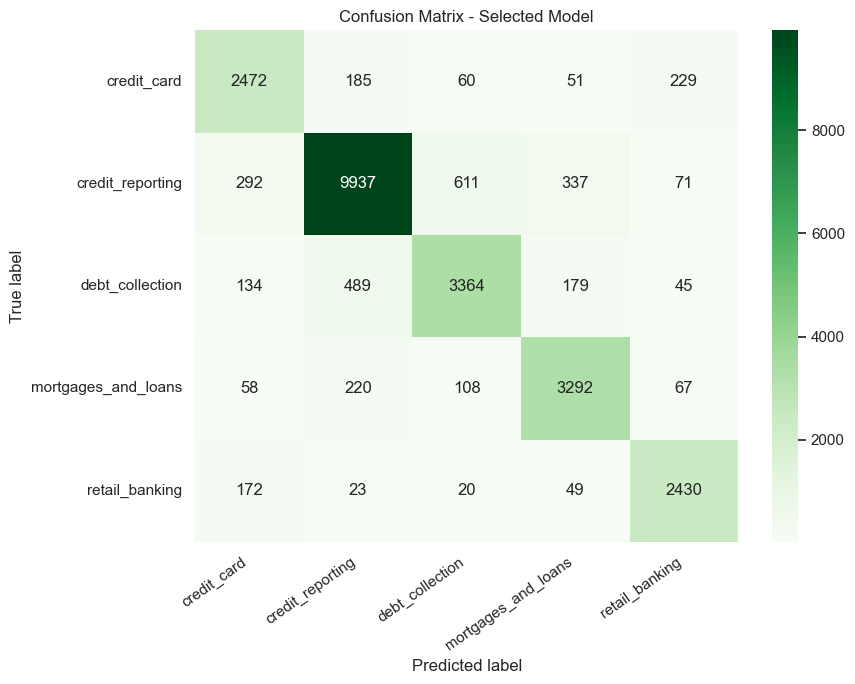

,actual,predicted,count
5,credit_reporting,debt_collection,611
9,debt_collection,credit_reporting,489
6,credit_reporting,mortgages_and_loans,337
4,credit_reporting,credit_card,292
3,credit_card,retail_banking,229
13,mortgages_and_loans,credit_reporting,220
0,credit_card,credit_reporting,185
10,debt_collection,mortgages_and_loans,179
16,retail_banking,credit_card,172
8,debt_collection,credit_card,134


In [11]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, test_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(9, 7))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix - Selected Model')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

confusion_pairs = []
for actual in labels:
    for predicted in labels:
        if actual != predicted:
            confusion_pairs.append({
                'actual': actual,
                'predicted': predicted,
                'count': cm_df.loc[actual, predicted],
            })

confusion_pairs = pd.DataFrame(confusion_pairs).sort_values('count', ascending=False)
display(confusion_pairs.head(10))

**Confusion matrix comments**

- The strongest confusion is still between `credit_reporting` and `debt_collection`.
- `credit_card` and `retail_banking` also overlap, which matches the EDA findings about shared banking vocabulary.
- `mortgages_and_loans` is mostly separated well, but it still has some overlap with `credit_reporting`.
- The next improvement should inspect examples from the largest confused pairs instead of only adding more model variants.

## 10. Error Review

In [12]:
errors = pd.DataFrame({
    'narrative': X_test,
    'actual': y_test,
    'predicted': test_pred,
})
errors = errors[errors['actual'] != errors['predicted']].copy()

print('Misclassified complaints:', len(errors))
print('Error rate:', round(len(errors) / len(X_test) * 100, 2), '%')

display(errors.sample(min(10, len(errors)), random_state=42))

Misclassified complaints: 3400
Error rate: 13.66 %


,narrative,actual,predicted
113438,mistakenly made double payment mortgage payment amount upon making mistake immediately called asked refund could processed advised refun...,mortgages_and_loans,retail_banking
111655,submitted dispute equifax update status collection account unpaid paid full attached letter collection company proof said account paid f...,debt_collection,credit_reporting
87871,wife diagnosed stage permanently missed mortgage payment month contacted mortgage company offered loan modification medical hardship sen...,credit_reporting,mortgages_and_loans
14236,dear cfpb waiting unemployment since borrow fund several different people make end meet finally get unemployment check bank charging fee...,retail_banking,credit_card
30374,contacting notify office egregious aggressive illegal debt collection tactic u bank engaging misled victimized misrepresentation made co...,mortgages_and_loans,debt_collection
86523,id theft discover account need removed ssn,debt_collection,credit_reporting
5273,reviewing credit report equifax noticed collection opened amount clue collection came never authorized action constitutes violation righ...,debt_collection,credit_reporting
63919,keep trying call credit card coronavirus wont answer,credit_reporting,credit_card
2904,account closing due new address changed since fax send received one calling every day one received said valid informed called fax sent v...,retail_banking,credit_card
37571,checked credit report back found unauthorized account opened name citibank name spelled incorrectly never opened another account citiban...,credit_card,retail_banking


**Error comments**

- The error rate is useful context, but the most important question is which classes produce those errors.
- Most remaining issues are likely caused by overlapping language across financial products.
- The largest confusion pairs should be reviewed manually before moving to a more complex model.

## 11. Final Takeaways

This notebook compares simple text-classification baselines before tuning. Bag of Words models are useful as a starting point, but TF-IDF with Linear SVM performs best on this dataset.

The selected model improves macro F1 slightly while staying simple and interpretable. The model is saved locally with `joblib`, and prediction examples show how it can route new complaint text by product category.

The main remaining limitation is category overlap, especially between `credit_reporting` and `debt_collection`.

Possible next steps:

- Add focused error analysis for the most confused class pairs
- Inspect feature weights for the selected Linear SVM model
- Try character n-grams for noisy text
- Build a small triage function that uses the predicted category to route complaints
- Add a GenAI layer only after the classifier and routing logic are clear